<a href="https://colab.research.google.com/github/Sunil032003/Restaurant-review-NLP-/blob/main/MCA_NPL_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer


# Download NLTK Resources

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')


# Sample Dataset

data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

df = pd.DataFrame(data)

# Stopwords

stop_words = set(stopwords.words('english'))


# Text Cleaning Function

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text


# Clean Reviews

df['cleaned_review'] = df['Review'].apply(clean_text)


# Sentiment Analysis

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    sentiment_scores = sia.polarity_scores(review)

    compound_score = sentiment_scores['compound']

    if compound_score >= 0.05:
        return "Positive"
    elif compound_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Predict Sentiment
df['sentiment'] = df['cleaned_review'].apply(analyze_sentiment)


# Display Results

print(df[['Review', 'cleaned_review', 'sentiment']])


# Sentiment Counts
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_review sentiment  
0   product quality excellent delivery fast  Positive  
1                bad packaging item damaged  Negative  
2       customer service helpful responsive  Positive  
3     delivery delayed support team respond  Positive  
4               amazing product worth money  Positive  
5  poor quality product terrible experience  Ne

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
from typing import Counter
all_words=" ".join(df['cleaned_review'])
word_list=all_words.split()

#count word frequency

word_freq=Counter(word_list)

#display top 10 keywords
print("\nTop 10 Keywords:")
print(word_freq.most_common(10))


Top 10 Keywords:
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
negative_review=df[df['sentiment']=='Negative']
negative_words=' '.join(negative_review['cleaned_review'])
negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)
print("\nNegative Keywords:")
print(complaint_freq.most_common(10))


Negative Keywords:
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


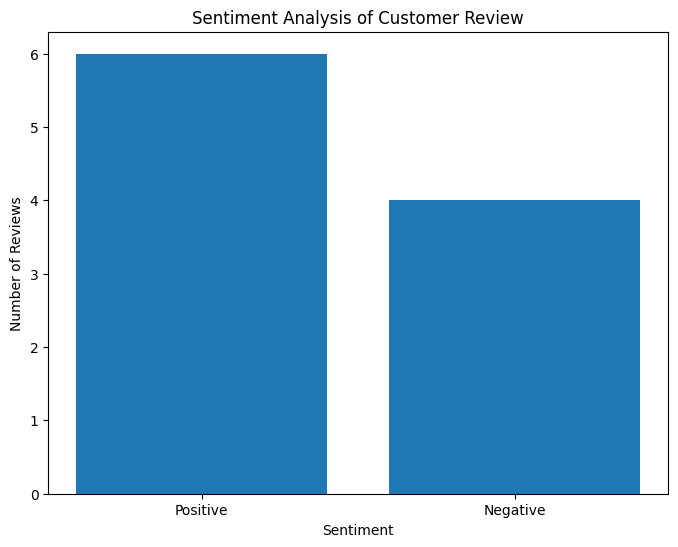

In [ ]:
import matplotlib.pyplot as plt
sentiment_counts=df['sentiment'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Analysis of Customer Review')
plt.show()


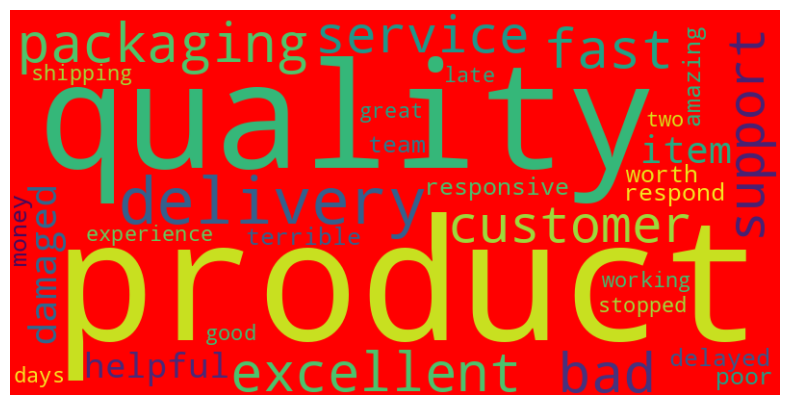

In [ ]:
from wordcloud import WordCloud as world_cloud
import matplotlib.pyplot as plt
world_cloud=world_cloud(
    width=800,
    height=400,
    background_color='red'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(world_cloud,interpolation='bilinear')
plt.axis('off')
plt.show()